In [ ]:
# Instalar versión compatible
!pip install wfdb==3.4.1

In [ ]:
# === LIBRERÍAS ===
import wfdb
import numpy as np
import pandas as pd
from scipy.stats import entropy
import os
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# === PARTE 1: Función de extracción de características por canal ===
def extract_features_emg(signal):
    feats = {
        "mean": np.mean(signal),
        "std": np.std(signal),
        "rms": np.sqrt(np.mean(signal**2)),
        "entropy": entropy(np.histogram(signal, bins=60)[0] + 1e-8),
    }
    return feats

In [ ]:
# === PARTE 2: Lectura de archivos .dat en carpeta específica ===
folder = 'Sujeto1'  # Cambia esto por el nombre de tu carpeta
all_features = []

for filename in os.listdir(folder):
    if filename.endswith('.dat') and "emg" in filename:
        file_path = os.path.join(folder, filename[:-4])  # sin extensión

        # Leer archivo EMG
        record = wfdb.rdrecord(file_path)
        emg_data = record.p_signal  # (n_samples x 448 canales)

        # Extraer características por canal
        for channel_index, channel in enumerate(emg_data.T):  # Transponer para recorrer por canal
            feats = extract_features_emg(channel)
            feats['file'] = filename
            feats['channel'] = channel_index
            all_features.append(feats)

# Crear DataFrame
df = pd.DataFrame(all_features)

In [ ]:
# === PARTE 3: Extraer el número de gesto desde el nombre del archivo ===
df["filename_clean"] = df["file"].str.replace(".dat", "", regex=False)
df["gesture_id"] = df["filename_clean"].apply(lambda x: x.split("_")[4])  # ej: '01', '02', ...

# (OPCIONAL) Mapeo de IDs de gesto a nombres reales
gesture_map = {
    "01": "Fist", "02": "Pinch", "03": "Flex Index", "04": "Flex Middle",
    "05": "Flex Ring", "06": "Flex Little", "07": "Open Hand", "08": "Thumb Up",
    "09": "Point", "10": "Peace", "11": "OK", "12": "Rock", "13": "Claw",
    "14": "Palm", "15": "Wrist Flexion", "16": "Wrist Extension",
    "17": "Rest", "18": "Grip", "19": "Release", "20": "Wave"
}
df["gesture_name"] = df["gesture_id"].map(gesture_map).fillna(df["gesture_id"])  # usa ID si no se encuentra el nombre


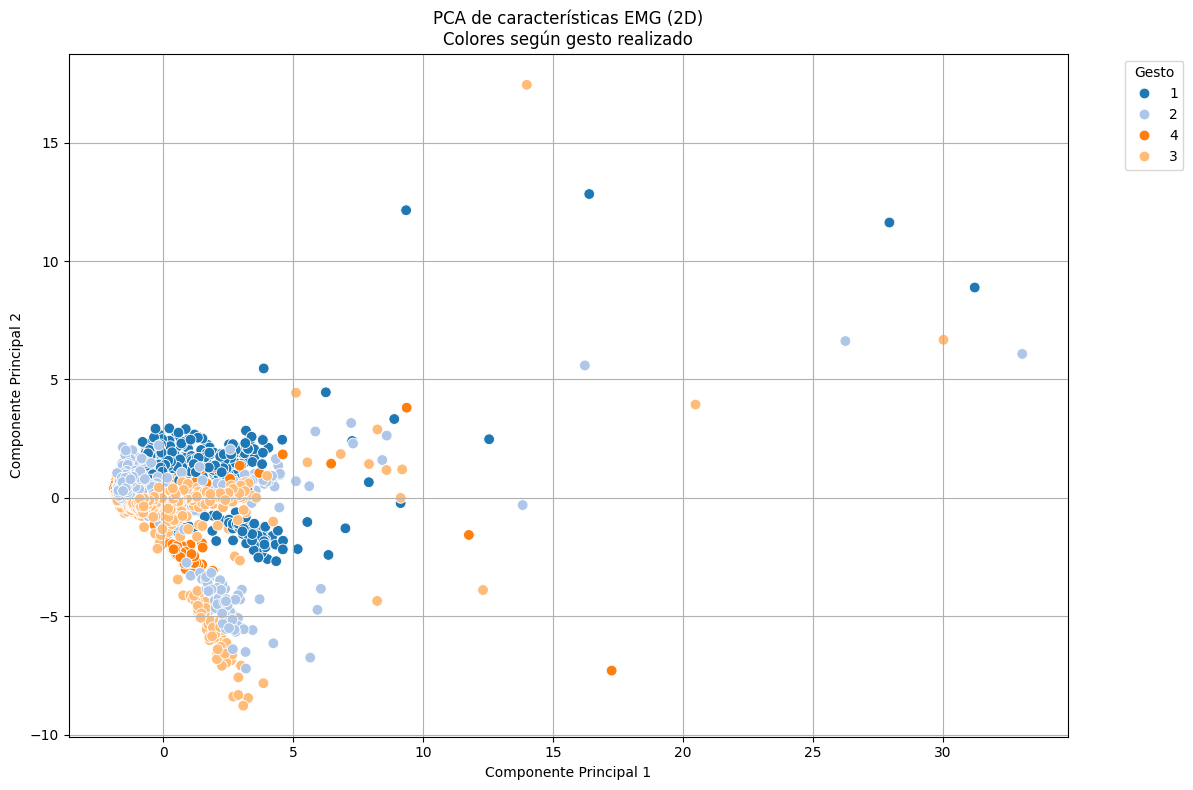

In [ ]:
# === PARTE 4: PCA y visualización ===

# Selección de columnas numéricas
X_raw = df.select_dtypes(include=[np.number]).copy()

# Escalado robusto
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X_raw)

# PCA a 2 dimensiones
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# DataFrame para graficar
pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["Gesto"] = df["gesture_name"]

# === GRAFICAR ===
plt.figure(figsize=(12, 8))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="Gesto", palette="tab20", s=60)
plt.title("PCA de características EMG (2D)\nColores según gesto realizado")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.legend(title="Gesto", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Mostrar resultado
print(df)

           mean          std          rms   entropy  \
0      1.228078   663.794911   663.796047  2.595130   
1      1.621096   758.686543   758.688275  2.611734   
2      3.037674   796.413597   796.419390  2.638075   
3     -0.390930   628.503813   628.503935  2.674539   
4     14.810265  1517.443709  1517.515981  2.346409   
...         ...          ...          ...       ...   
3131  -1.056989   344.043820   344.045444  2.320171   
3132  -1.149414   342.835211   342.837138  2.193273   
3133  -0.922422   317.835964   317.837303  2.246325   
3134  -1.763209   328.621167   328.625898  2.648643   
3135  -6.493358   900.995530   901.018928  2.993412   

                                  file  channel                filename_clean  \
0     hdkw_kin_exp01_subj01_1_emg0.dat        0  hdkw_kin_exp01_subj01_1_emg0   
1     hdkw_kin_exp01_subj01_1_emg0.dat        1  hdkw_kin_exp01_subj01_1_emg0   
2     hdkw_kin_exp01_subj01_1_emg0.dat        2  hdkw_kin_exp01_subj01_1_emg0   
3     hdkw_kin_